# Input-output properties cells

In [ ]:
import os
os.chdir('../sim')

In [ ]:
# !nrnivmodl -coreneuron mod/
!nrnivmodl mod_CA1/

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# NetPyNE

In [2]:
from netpyne import specs, sim   

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [3]:
popList = ['SP_PC','TRI','SCA','PVBC','PPA','OLM','NGF','IVY','CCKBC','BS','BP','AA']

cellTypeList = {}
cellTypeList["SP_PC"] = "poolosyncell"
cellTypeList["TRI"] = "pvbasketcell"
cellTypeList["SCA"] = "scacell"
cellTypeList["PVBC"] = "pvbasketcell"
cellTypeList["PPA"] = "pvbasketcell"
cellTypeList["OLM"] = "olmcell"
cellTypeList["NGF"] = "ngfcell"
cellTypeList["IVY"] = "ivycell"
cellTypeList["CCKBC"] = "cckcell"
cellTypeList["BS"] = "bistratifiedcell"
cellTypeList["BP"] = "pvbasketcell"
cellTypeList["AA"] = "axoaxoniccell"

for pop in cellTypeList.keys():
    
    cellName = cellTypeList[pop]
    hocName = "class_" + cellName + ".hoc"
    print(pop,cellName, hocName)
    # Load cell rules previously saved using netpyne format  
    netParams.loadCellParamsRule(label = pop, fileName = 'cells/' + cellName + '_cellParams.pkl')   

    cellRule = {}  # cell rule dict
    cellRule['conds'] = {}
    cellRule['conds']['cellType'] = pop
    cellRule['conds']['cellModel'] = netParams.cellParams[pop]['conds']['cellModel'] 
    cellRule['secs'] = {}
    cellRule['secs'] = netParams.cellParams[pop]['secs']
    cellRule['secLists'] = {}
    cellRule['secLists']['all'] = list(cellRule['secs'].keys())
    cellRule['secLists']['basal'] = [sec for sec in cellRule['secs'] if 'dend' in sec]
    cellRule['secLists']['apical'] = [sec for sec in cellRule['secs'] if 'apic' in sec]
    netParams.cellParams[pop] = cellRule   # add dict to list of cell params   

SP_PC poolosyncell class_poolosyncell.hoc
TRI pvbasketcell class_pvbasketcell.hoc
SCA scacell class_scacell.hoc
PVBC pvbasketcell class_pvbasketcell.hoc
PPA pvbasketcell class_pvbasketcell.hoc
OLM olmcell class_olmcell.hoc
NGF ngfcell class_ngfcell.hoc
IVY ivycell class_ivycell.hoc
CCKBC cckcell class_cckcell.hoc
BS bistratifiedcell class_bistratifiedcell.hoc
BP pvbasketcell class_pvbasketcell.hoc
AA axoaxoniccell class_axoaxoniccell.hoc


In [4]:
netParams.cellParams[pop]['conds'] 

{'cellType': 'AA', 'cellModel': 'HH_full'}

In [5]:
# ampstim = [round(x,2)for x in np.arange(-0.3, 0.55, 0.05)]
ampstim = [round(x,2)for x in np.arange(0.3, 0.55, 0.3)]
numero_de_celulas = len(ampstim)

for cell in netParams.cellParams.keys():
    netParams.popParams[cell] = {'cellType': cell, 'numCells': numero_de_celulas, 'cellModel': 'HH_full'}
    print(netParams.cellParams[cell])

print(f"Amplitudes geradas: {ampstim}")
print(f"Total de células criadas: {numero_de_celulas}")

{'conds': {'cellType': 'SP_PC', 'cellModel': 'HH_full'}, 'secs': {soma_0: {geom: {L: 0.5, nseg: 1, diam: 3.4000000953674316, Ra: 150.0, cm: 1.0, pt3d: [(0.0, 0.0, 0.0, 3.4000000953674316), (0.0, 0.25, 0.0, 3.4000000953674316), (0.0, 0.5, 0.0, 3.4000000953674316)]}, topol: {}, mechs: {ch_HCNp: {e: -30.0, gmax: 0.0006, vhalfl: -82.0}, ch_Kdrp: {e: 0.0, gmax: 0.003}, ch_KvAproxp: {gmax: 0.008, e: 0.0}, ch_Navp: {gmax: 0.032, ar2: 1.0, e: 0.0}, pas: {g: 3.571428571428572e-05, e: -66.0}}, ions: {k: {e: -90.0, i: 54.4, o: 2.5}, na: {e: 55.0, i: 10.0, o: 140.0}}, vinit: -60.0}, soma_1: {geom: {L: 0.10000002384185791, nseg: 1, diam: 3.4000000953674316, Ra: 150.0, cm: 1.0, pt3d: [(0.0, 0.5, 0.0, 3.4000000953674316), (0.0, 0.550000011920929, 0.0, 3.4000000953674316), (0.0, 0.6000000238418579, 0.0, 3.4000000953674316)]}, topol: {parentSec: 'soma_0', parentX: 1.0, childX: 0.0}, mechs: {ch_HCNp: {e: -30.0, gmax: 0.0006, vhalfl: -82.0}, ch_Kdrp: {e: 0.0, gmax: 0.003}, ch_KvAproxp: {gmax: 0.008, e: 0

In [6]:
durationstim = 1000.0
delaystim = 50.0
timesimulation = 1100.0

for cell in netParams.cellParams.keys():
    for i, amp in enumerate(ampstim):
        
        nome_source = f'Input_{i}'
        netParams.stimSourceParams[nome_source] = {
            'type': 'IClamp', 
            'del': delaystim, 
            'dur': durationstim, 
            'amp': amp
        }
        
        nome_target = f'Input->{cell}_{i}'
        netParams.stimTargetParams[nome_target] = {
            'source': nome_source, 
            'sec': 'soma_0', 
            'loc': 0.5, 
            'conds': {
                'pop': cell, 
            }
        }

In [7]:
netParams.stimTargetParams

{Input->SP_PC_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'SP_PC'}}, Input->TRI_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'TRI'}}, Input->SCA_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'SCA'}}, Input->PVBC_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'PVBC'}}, Input->PPA_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'PPA'}}, Input->OLM_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'OLM'}}, Input->NGF_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'NGF'}}, Input->IVY_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'IVY'}}, Input->CCKBC_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'CCKBC'}}, Input->BS_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 'BS'}}, Input->BP_0: {'source': 'Input_0', 'sec': 'soma_0', 'loc': 0.5, 'conds': {'pop': 

In [8]:
## cfg  
cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration
cfg.duration = timesimulation 						            # Duration of the simulation, in ms
cfg.dt = 0.025								                # Internal integration timestep to use
cfg.verbose = False	
cfg.recordCells = ['all']						                # Show detailed messages 
cfg.recordTraces = {'V_soma':{'sec':'soma_0','loc':0.5,'var':'v'}}  # Dict with traces to record
cfg.recordStep = 0.025 			
cfg.filename = 'model_inh'  			# Set file output name
cfg.saveJson = False
cfg.hParams = {'celsius': 34, 'v_init': -66.0}  

cfg.createNEURONObj = True
cfg.createPyStruct = True  
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

In [9]:
sim.initialize(
    simConfig = cfg, 	
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations


Start time:  2026-04-07 14:42:52.669811


{SP_PC: <netpyne.network.pop.Pop object at 0x7f42839fac10>, TRI: <netpyne.network.pop.Pop object at 0x7f42839faf40>, SCA: <netpyne.network.pop.Pop object at 0x7f42839fa160>, PVBC: <netpyne.network.pop.Pop object at 0x7f42839fae50>, PPA: <netpyne.network.pop.Pop object at 0x7f42839faee0>, OLM: <netpyne.network.pop.Pop object at 0x7f42839fae20>, NGF: <netpyne.network.pop.Pop object at 0x7f42839fadf0>, IVY: <netpyne.network.pop.Pop object at 0x7f42839fa610>, CCKBC: <netpyne.network.pop.Pop object at 0x7f42839fafd0>, BS: <netpyne.network.pop.Pop object at 0x7f42839fa790>, BP: <netpyne.network.pop.Pop object at 0x7f42839fa490>, AA: <netpyne.network.pop.Pop object at 0x7f42839fa100>}

In [10]:
sim.net.createCells()              			# instantiate network cells based on defined populations


Creating network of 12 cell populations on 1 hosts...
  Number of cells on node 0: 12 
  Done; cell creation time = 0.02 s.


[compartCell_SP_PC_HH_full_0,
 compartCell_TRI_HH_full_1,
 compartCell_SCA_HH_full_2,
 compartCell_PVBC_HH_full_3,
 compartCell_PPA_HH_full_4,
 compartCell_OLM_HH_full_5,
 compartCell_NGF_HH_full_6,
 compartCell_IVY_HH_full_7,
 compartCell_CCKBC_HH_full_8,
 compartCell_BS_HH_full_9,
 compartCell_BP_HH_full_10,
 compartCell_AA_HH_full_11]

In [11]:
sim.net.connectCells()            			# create connections between cells based on params

Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.


[[], [], [], [], [], [], [], [], [], [], [], []]

In [12]:
sim.net.addStims() 							# add network stimulation

Adding stims...
  Number of stims on node 0: 12 
  Done; cell stims creation time = 0.00 s.


[[{label: 'Input->SP_PC_0', source: 'Input_0', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 50.0, dur: 1000.0, amp: 0.3, hObj: IClamp[0]}],
 [{label: 'Input->TRI_0', source: 'Input_0', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 50.0, dur: 1000.0, amp: 0.3, hObj: IClamp[1]}],
 [{label: 'Input->SCA_0', source: 'Input_0', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 50.0, dur: 1000.0, amp: 0.3, hObj: IClamp[2]}],
 [{label: 'Input->PVBC_0', source: 'Input_0', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 50.0, dur: 1000.0, amp: 0.3, hObj: IClamp[3]}],
 [{label: 'Input->PPA_0', source: 'Input_0', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 50.0, dur: 1000.0, amp: 0.3, hObj: IClamp[4]}],
 [{label: 'Input->OLM_0', source: 'Input_0', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 50.0, dur: 1000.0, amp: 0.3, hObj: IClamp[5]}],
 [{label: 'Input->NGF_0', source: 'Input_0', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 50.0, dur: 1000.0, amp: 0.3, hObj: IClamp[6]}],
 [{label: 'Input->IVY_0'

In [13]:
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)

Recording 12 traces of 1 types on node 0


{spkt: Vector[0], spkid: Vector[1], V_soma: {cell_0: Vector[2], cell_1: Vector[3], cell_2: Vector[4], cell_3: Vector[5], cell_4: Vector[6], cell_5: Vector[7], cell_6: Vector[8], cell_7: Vector[9], cell_8: Vector[10], cell_9: Vector[11], cell_10: Vector[12], cell_11: Vector[13]}, t: Vector[14], _repr_mimebundle_: {}}

In [14]:
sim.runSim()                      			# run parallel Neuron simulation  

0.0s

Running simulation using NEURON for 1100.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
0.7s
0.8s
0.9s
1.0s
1.1s
  Done; run time = 7.12 s; real-time ratio: 0.15.


In [15]:
sim.gatherData();                  			# gather spiking data and cell info from each node


Gathering data...
  Done; gather time = 0.02 s.

Analyzing...
  Cells: 12
  Connections: 0 (0.00 per cell)
  Spikes: 314 (23.79 Hz)
  Simulated time: 1.1 s; 1 workers
  Run time: 7.12 s
   SP_PC : 22.727 Hz
   TRI : 6.364 Hz
   SCA : 40.000 Hz
   PVBC : 6.364 Hz
   PPA : 6.364 Hz
   OLM : 79.091 Hz
   NGF : 25.455 Hz
   IVY : 25.455 Hz
   CCKBC : 30.000 Hz
   BS : 0.000 Hz
   BP : 6.364 Hz
   AA : 37.273 Hz


In [16]:
sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
sim.analysis.plotData()         			# plot spike raster etc

  Done; plotting time = 0.00 s

Total time = 7.21 s


Plotting recorded cell traces ... cell


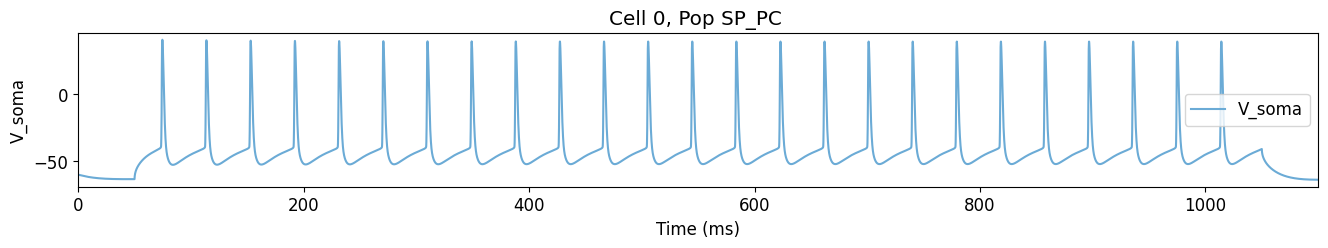

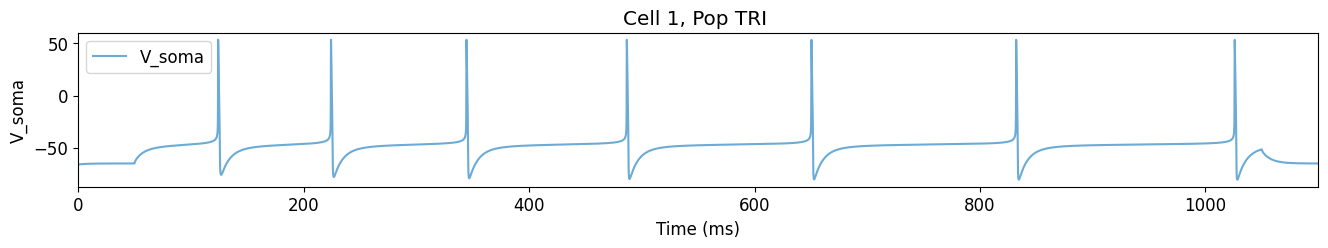

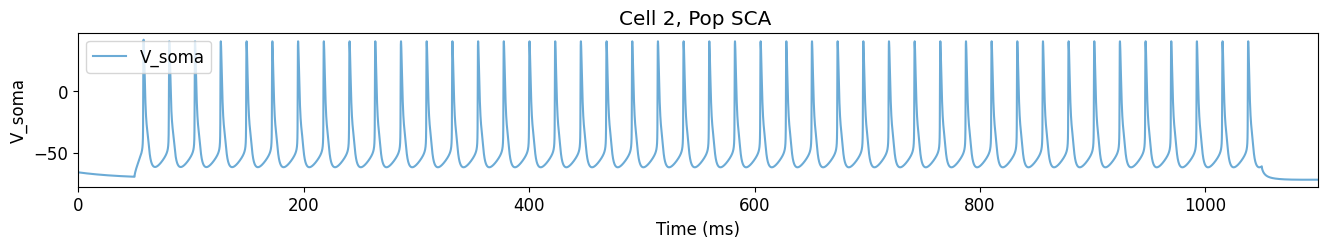

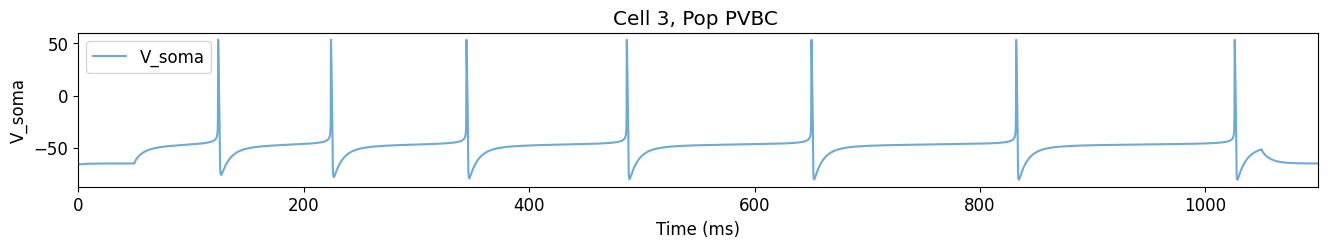

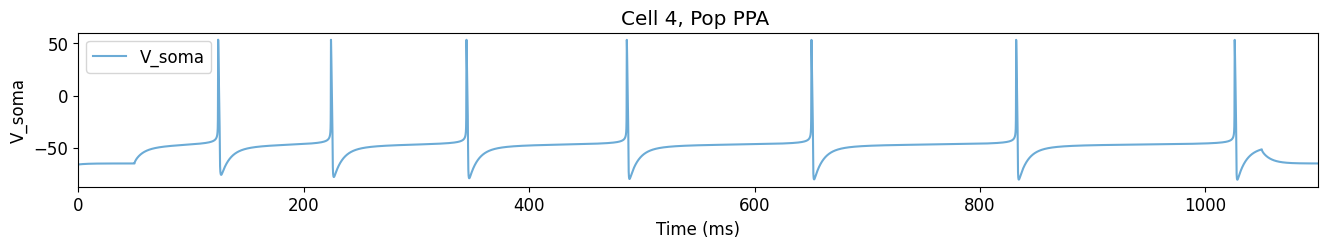

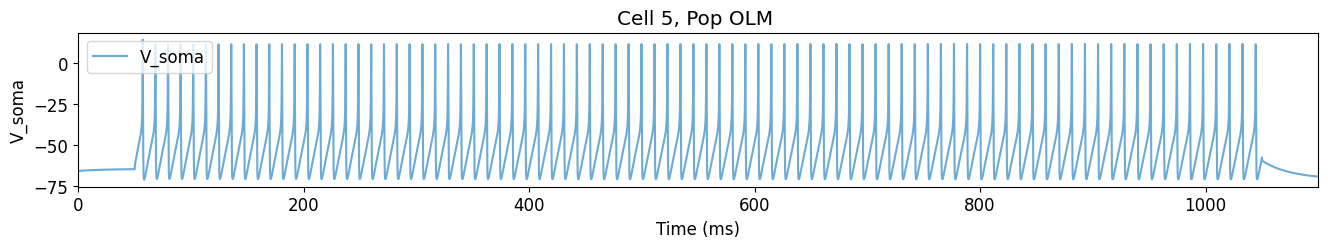

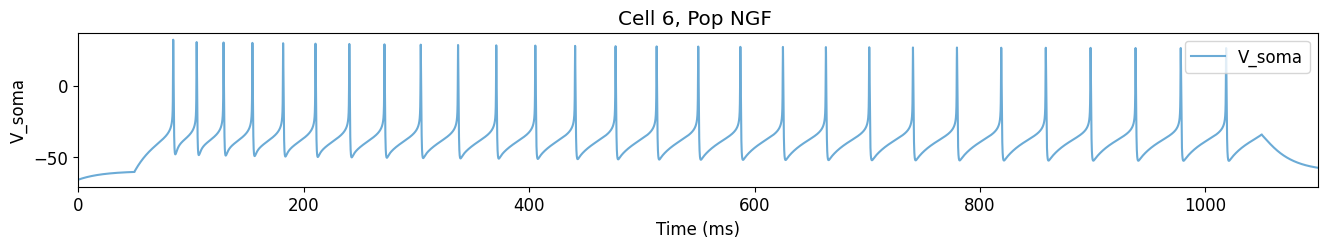

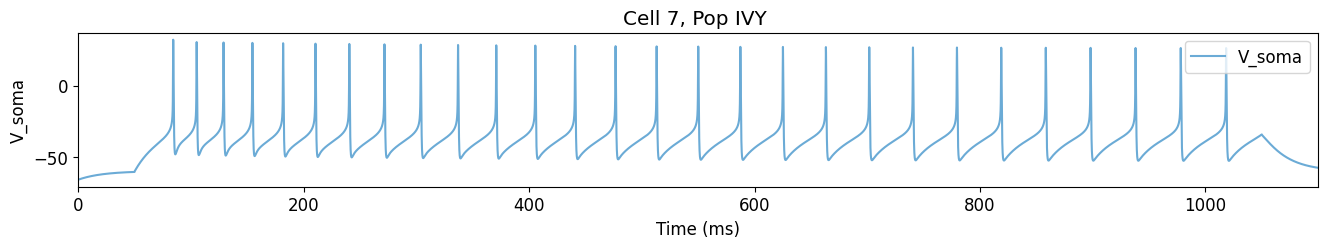

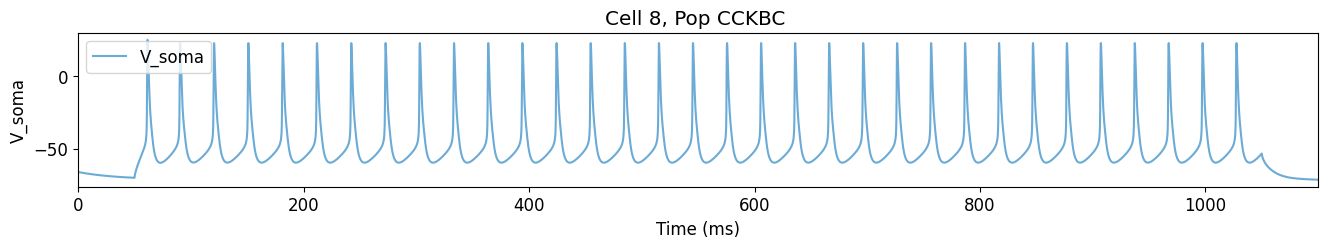

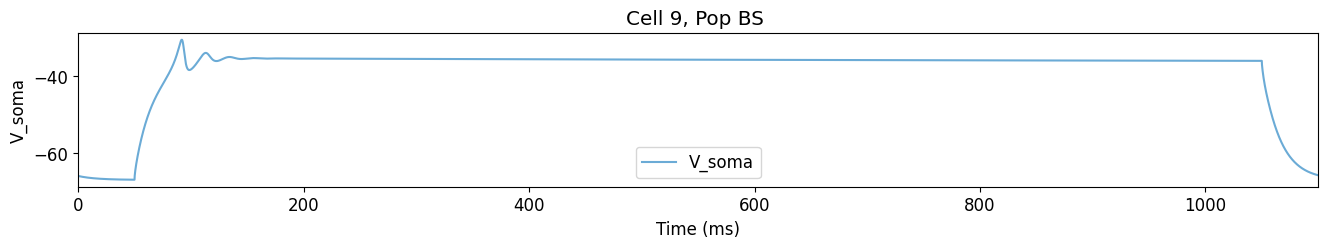

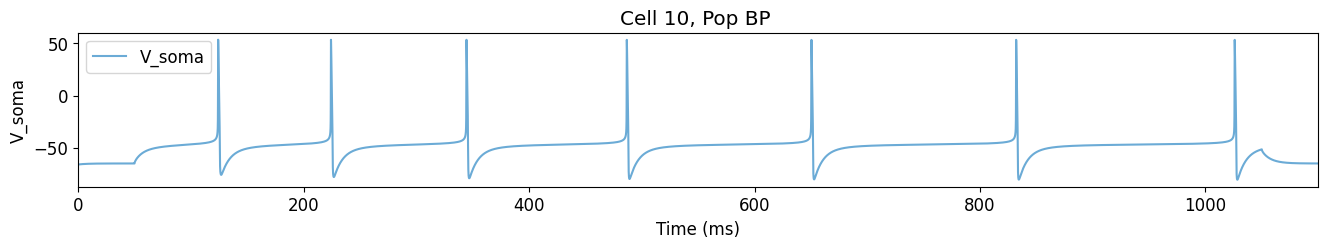

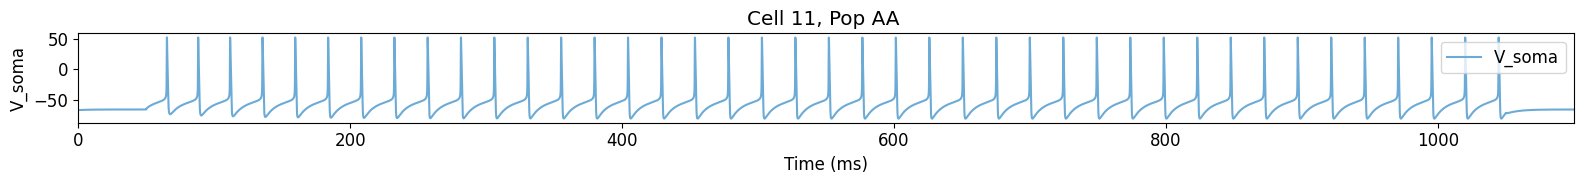

In [17]:
sim.analysis.plotTraces(oneFigPer='cell', overlay='true', figSize=(16,2));

Plotting 3D cell shape ...


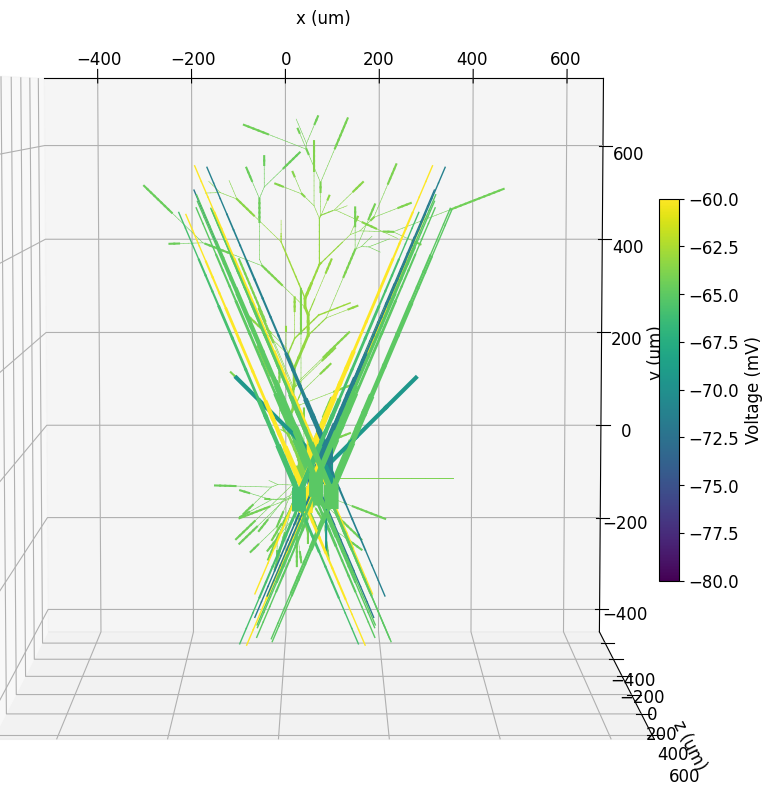

In [18]:
sim.analysis.plotShape(includePre=['all'], includePost=['all'], includeAxon=True, showSyns=False, showElectrodes=False,
    cvar= 'voltage', dist=0.6, elev=95, azim=-90, 
    axisLabels=True, synStyle='o', 
    clim= [-80, -60], showFig=True, synSize=2, saveFig=False, figSize=(8,8));

In [19]:
# for i in range(9):
#     sim.analysis.plotShape(includePre=[i], includePost=[i], includeAxon=True, showSyns=False, showElectrodes=False,
#         cvar= 'voltage', dist=0.6, elev=95, azim=-90, 
#         axisLabels=True, synStyle='o', 
#         clim= [-80, -60], showFig=True, synSize=2, saveFig=False, figSize=(8,8)); 

Plotting connectivity matrix...


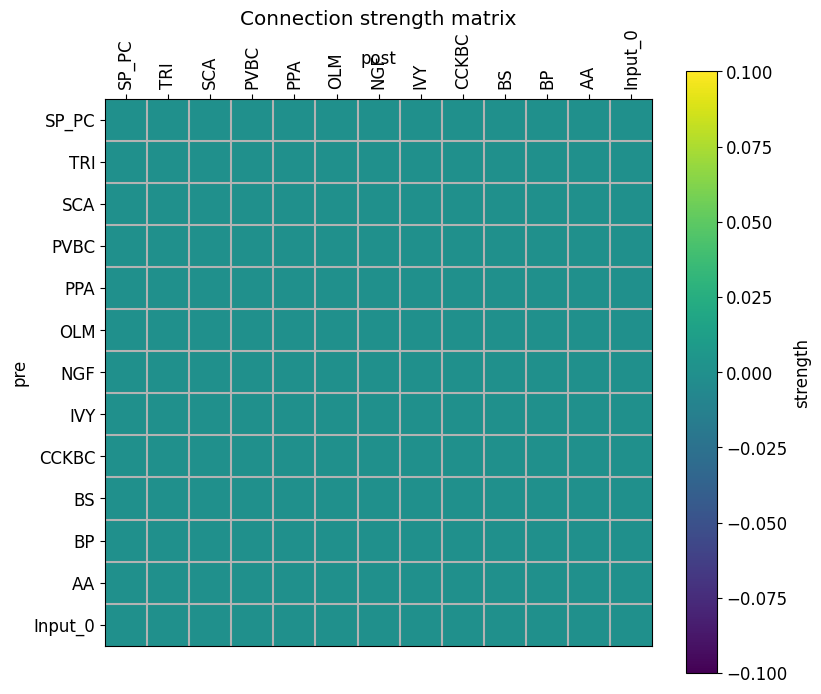

(<Figure size 800x800 with 2 Axes>,
 {'connMatrix': array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.

In [20]:
sim.analysis.plotConn(graphType='matrix', saveFig=False)